In [0]:
!pip install seaborn

Looking in indexes: [REDACTED]
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
"""Imports and plot style / imports e estilo dos gráficos."""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from pyspark.sql import functions as F

# show all columns without truncation / mostra todas as colunas sem cortar
pd.set_option("display.max_columns", None)

# color palette / paleta de cores
COR_PRIMARIA = "#0072B2"
COR_SECUNDARIA = "#94A3B8"
COR_DESTAQUE = "#E69F00"

# global plot parameters / parâmetros globais dos gráficos
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

In [0]:
"""Load the silver table / carrega a tabela silver."""

# silver transactions without personal data / transações silver sem dados pessoais
df = spark.table("workspace.silver.transactions")
print(df.count(), df.columns)
display(df.limit(5))

34636378 ['trans_num', 'customer_hash', 'event_time', 'amt', 'category', 'merchant', 'state', 'city_pop', 'gender', 'job', 'age', 'distance_km', 'hour', 'day_of_week', 'month', 'is_fraud']


trans_num,customer_hash,event_time,amt,category,merchant,state,city_pop,gender,job,age,distance_km,hour,day_of_week,month,is_fraud
713d80949b744634aaf6333bc17c07c2,2700b8b86ed1f79fc30ceffe813dc12f8c07ac0fd5e6909a1adb6f94d582458d,2020-12-16T19:23:24.000Z,53.42,personal_care,fraud_Osinski Inc,AL,16261,M,Management consultant,36,95.75,19,4,12,0
ce47fdec604777fc37444ab424ae3ab1,2700b8b86ed1f79fc30ceffe813dc12f8c07ac0fd5e6909a1adb6f94d582458d,2020-12-05T14:18:31.000Z,1.43,personal_care,fraud_Labadie LLC,AL,16261,M,Management consultant,36,105.74,14,7,12,0
716c1f15822ddafc2b301d57abd44992,2700b8b86ed1f79fc30ceffe813dc12f8c07ac0fd5e6909a1adb6f94d582458d,2020-12-17T19:23:59.000Z,12.92,personal_care,fraud_Monahan-Morar,AL,16261,M,Management consultant,36,107.34,19,5,12,0
2ef539acc6213da390ca90830ad2b47d,2700b8b86ed1f79fc30ceffe813dc12f8c07ac0fd5e6909a1adb6f94d582458d,2020-04-16T15:04:17.000Z,2.06,food_dining,fraud_Harris Group,AL,16261,M,Management consultant,35,103.75,15,5,4,0
8f301b4c2432456e511dc93a521b5619,2700b8b86ed1f79fc30ceffe813dc12f8c07ac0fd5e6909a1adb6f94d582458d,2020-10-30T13:18:52.000Z,2.19,kids_pets,fraud_Bernier and Sons,AL,16261,M,Management consultant,35,104.52,13,6,10,0


In [0]:
"""Fraud rate by category / taxa de fraude por categoria."""

# aggregate in spark, bring only the summary to pandas / agrega no spark e leva só o resumo para o pandas
por_categoria = (
    df.groupBy("category")
    .agg(F.count("*").alias("n"), F.sum("is_fraud").alias("fraudes"), F.avg("is_fraud").alias("taxa"))
    .toPandas()
    .sort_values("taxa", ascending=False)
)
por_categoria

,category,n,fraudes,taxa
12,shopping_net,2543488,44323,0.017426
13,misc_net,1578517,24662,0.015624
3,grocery_pos,3266890,43877,0.013431
10,shopping_pos,3418709,22607,0.006613
1,gas_transport,2980489,15350,0.005150
5,travel,1106289,2952,0.002668
9,misc_pos,2277880,5897,0.002589
8,personal_care,2447892,5387,0.002201
11,entertainment,2517230,5474,0.002175
0,grocery_net,1469923,3035,0.002065


In [0]:
"""Target distribution / distribuição da variável alvo."""

# count each class in spark and bring the small result to pandas / conta cada classe no spark e leva o resultado pequeno para o pandas
alvo = df.groupBy("is_fraud").count().toPandas().sort_values("is_fraud")
alvo["classe"] = alvo["is_fraud"].map({0: "legítima", 1: "fraude"})
alvo["pct"] = alvo["count"] / alvo["count"].sum() * 100
alvo

,is_fraud,count,classe,pct
1,0,34446453,legítima,99.45166
0,1,189925,fraude,0.54834


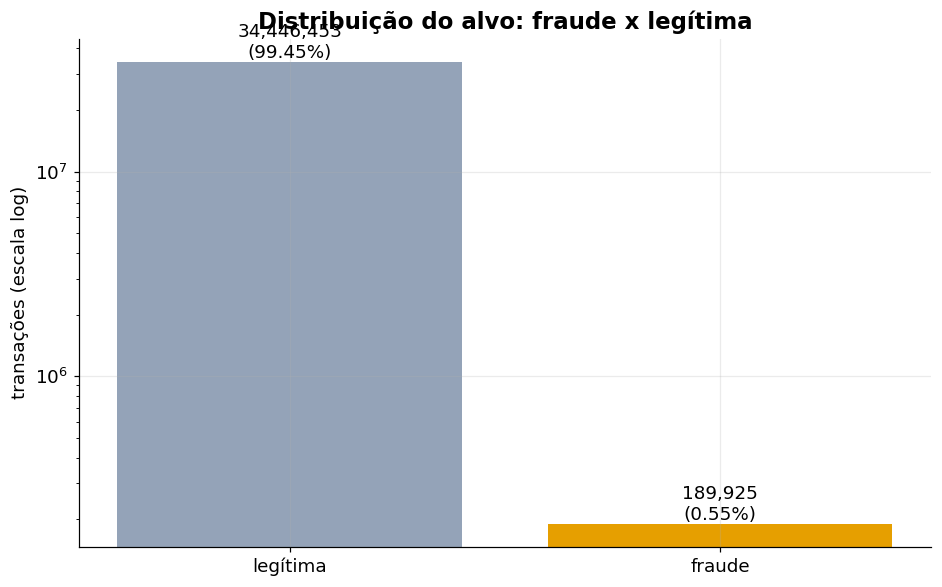

1 fraude para cada 181 transações legítimas


In [0]:
"""Plot target distribution / gráfico da distribuição do alvo."""

# log scale keeps the small fraud class visible / escala log mantém a classe pequena de fraude visível
fig, ax = plt.subplots()
barras = ax.bar(alvo["classe"], alvo["count"], color=[COR_SECUNDARIA, COR_DESTAQUE])
ax.set_yscale("log")

# label each bar with count and percentage / rotula cada barra com contagem e percentual
for barra, n, pct in zip(barras, alvo["count"], alvo["pct"]):
    ax.text(barra.get_x() + barra.get_width() / 2, n, f"{n:,.0f}\n({pct:.2f}%)", ha="center", va="bottom")

ax.set_title("Distribuição do alvo: fraude x legítima")
ax.set_ylabel("transações (escala log)")
plt.show()

"""Class imbalance ratio / razão de desbalanceamento das classes."""

# legitimate transactions per fraud / transações legítimas para cada fraude
razao = alvo.loc[alvo["is_fraud"] == 0, "count"].iloc[0] / alvo.loc[alvo["is_fraud"] == 1, "count"].iloc[0]
print(f"1 fraude para cada {razao:,.0f} transações legítimas")

In [0]:
"""Correlation matrix on the full silver table / matriz de correlação na silver inteira."""

from itertools import combinations

# numeric columns plus the target / colunas numéricas mais o alvo
cols = ["amt", "age", "distance_km", "city_pop", "hour", "day_of_week", "month", "is_fraud"]

# all pairwise correlations in a single spark pass / todas as correlações par a par em uma única passada do spark
pares = list(combinations(cols, 2))
linha = df.select([F.corr(a, b).alias(f"{a}|{b}") for a, b in pares]).first()

# symmetric matrix with 1.0 on the diagonal / matriz simétrica com 1,0 na diagonal
corr = pd.DataFrame(1.0, index=cols, columns=cols)
for (a, b), valor in zip(pares, linha):
    corr.loc[a, b] = valor
    corr.loc[b, a] = valor
corr.round(3)

,amt,age,distance_km,city_pop,hour,day_of_week,month,is_fraud
amt,1.000,0.004,0.000,0.000,-0.025,-0.003,-0.021,0.207
age,0.004,1.000,0.000,-0.004,-0.202,-0.024,0.016,0.019
distance_km,0.000,0.000,1.000,0.009,0.000,-0.000,-0.000,0.000
city_pop,0.000,-0.004,0.009,1.000,-0.000,-0.000,-0.000,0.000
hour,-0.025,-0.202,0.000,-0.000,1.000,-0.001,0.313,0.007
day_of_week,-0.003,-0.024,-0.000,-0.000,-0.001,1.000,-0.010,-0.006
month,-0.021,0.016,-0.000,-0.000,0.313,-0.010,1.000,-0.014
is_fraud,0.207,0.019,0.000,0.000,0.007,-0.006,-0.014,1.000


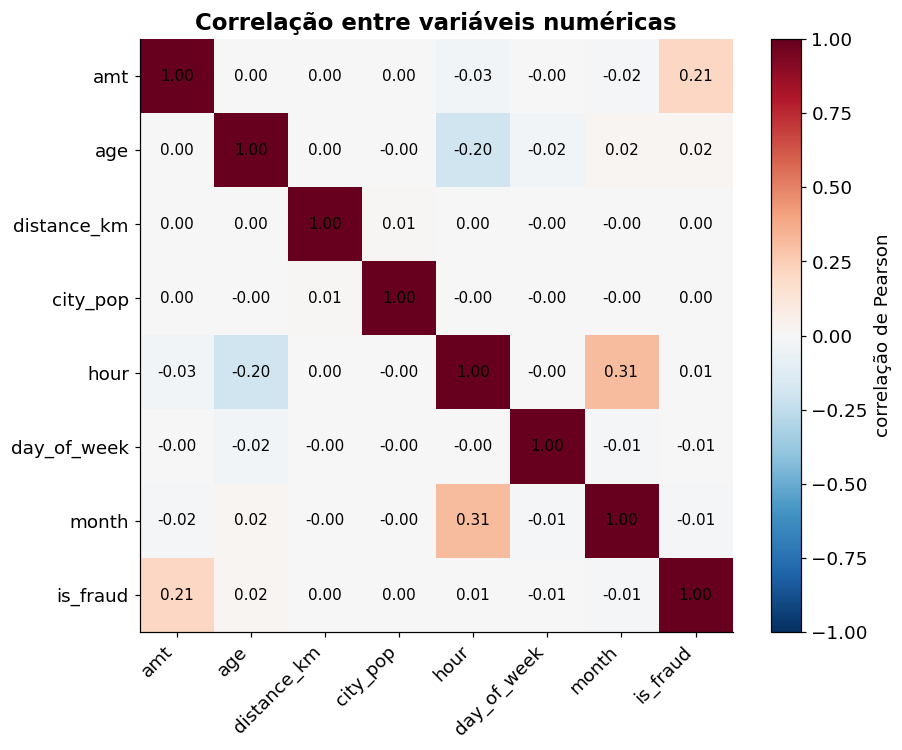

In [0]:
"""Plot correlation heatmap / gráfico do mapa de calor de correlação."""

# diverging colormap centered on zero / mapa de cores divergente centrado em zero
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)), cols, rotation=45, ha="right")
ax.set_yticks(range(len(cols)), cols)
ax.grid(False)

# write the value inside each cell / escreve o valor dentro de cada célula
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10)

plt.colorbar(im, label="correlação de Pearson")
ax.set_title("Correlação entre variáveis numéricas")
plt.show()

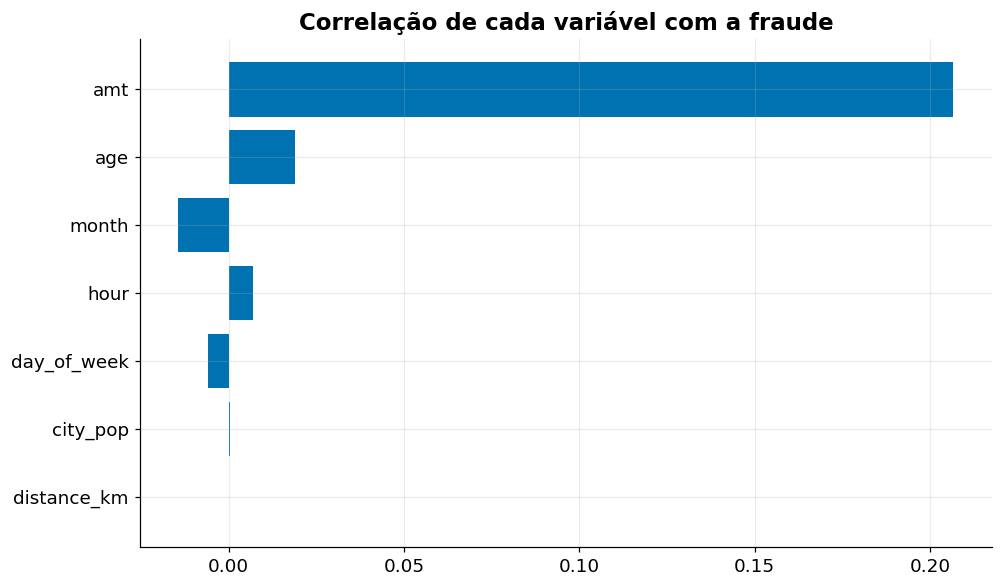

In [0]:
"""Correlation with the target / correlação com o alvo."""

# drop the target itself and sort by absolute value / remove o próprio alvo e ordena pelo valor absoluto
com_alvo = corr["is_fraud"].drop("is_fraud").sort_values(key=abs)

plt.barh(com_alvo.index, com_alvo.values, color=COR_PRIMARIA)
plt.title("Correlação de cada variável com a fraude")
plt.show()

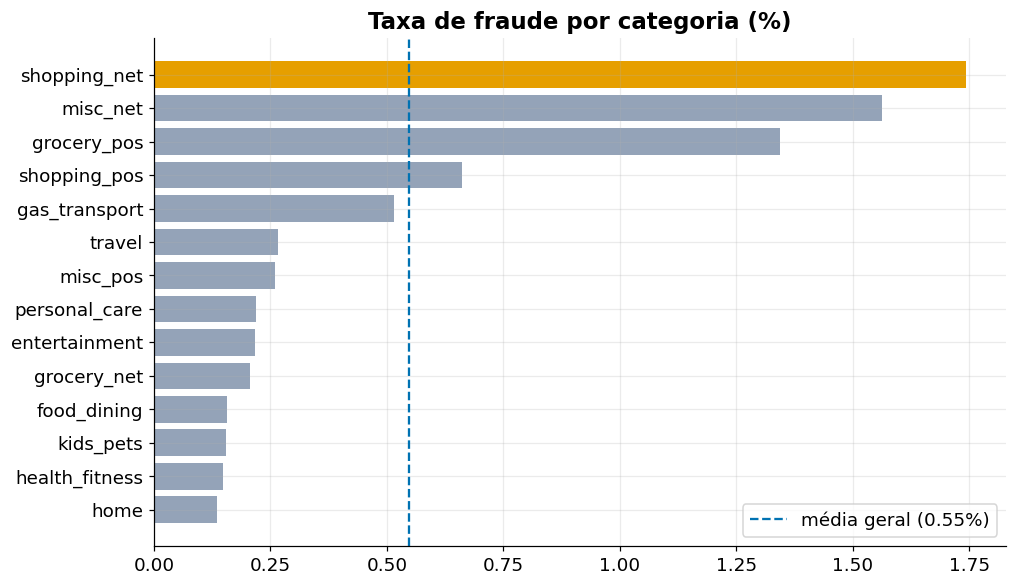

In [0]:
"""Plot fraud rate by category / gráfico da taxa de fraude por categoria."""

# overall fraud rate as reference line / taxa geral de fraude como linha de referência
taxa_geral = por_categoria["fraudes"].sum() / por_categoria["n"].sum() * 100

# bars sorted by rate, top category highlighted / barras ordenadas pela taxa, categoria líder destacada
dados = por_categoria.sort_values("taxa")
cores = [COR_SECUNDARIA] * (len(dados) - 1) + [COR_DESTAQUE]
plt.barh(dados["category"], dados["taxa"] * 100, color=cores)
plt.axvline(taxa_geral, color=COR_PRIMARIA, linestyle="--", label=f"média geral ({taxa_geral:.2f}%)")
plt.title("Taxa de fraude por categoria (%)")
plt.legend()
plt.show()

In [0]:
"""Stratified sample for distributions / amostra estratificada para distribuições."""

# keep all frauds and 0.6% of legitimate rows / mantém todas as fraudes e 0,6% das legítimas
amostra = df.sampleBy("is_fraud", fractions={0: 0.006, 1: 1.0}, seed=42).toPandas()
amostra["classe"] = amostra["is_fraud"].map({0: "legítima", 1: "fraude"})
amostra.groupby("classe").size().to_frame("n")

,n
classe,
fraude,189925
legítima,207473


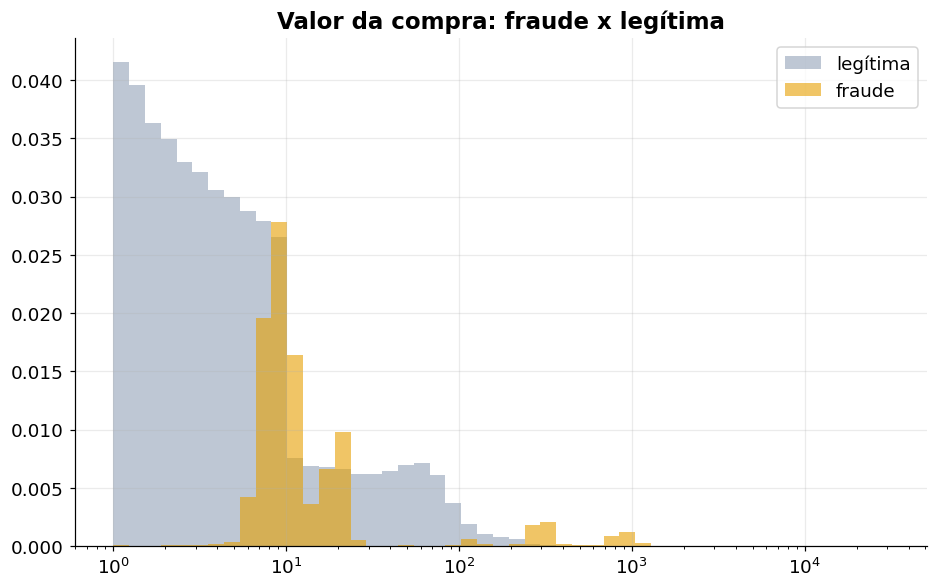

,count,mean,std,min,25%,50%,75%,max
classe,,,,,,,,
fraude,189925.0,537.972642,393.055120,1.01,255.54,448.60,913.21,1525.46
legítima,207473.0,68.484675,174.425058,1.00,9.09,44.31,81.21,30491.53


In [0]:
# log-scale bins, density normalizes each class / bins em escala log, densidade normaliza cada classe
piso = max(amostra["amt"].min(), 0.01)
bins = np.logspace(np.log10(piso), np.log10(amostra["amt"].max()), 50)
for classe, cor in [("legítima", COR_SECUNDARIA), ("fraude", COR_DESTAQUE)]:
    plt.hist(amostra.loc[amostra["classe"] == classe, "amt"], bins=bins, density=True, alpha=0.6, color=cor, label=classe)
plt.xscale("log")
plt.title("Valor da compra: fraude x legítima")
plt.legend()
plt.show()
amostra.groupby("classe")["amt"].describe()

In [0]:
"""Fraud rate by amount band / taxa de fraude por faixa de valor."""

# amount bands, numbered so they sort correctly / faixas de valor numeradas para ordenar corretamente
faixa = (
    F.when(F.col("amt") < 10, "1. até 10")
    .when(F.col("amt") < 50, "2. 10 a 50")
    .when(F.col("amt") < 100, "3. 50 a 100")
    .when(F.col("amt") < 250, "4. 100 a 250")
    .when(F.col("amt") < 500, "5. 250 a 500")
    .when(F.col("amt") < 1000, "6. 500 a 1000")
    .otherwise("7. acima de 1000")
)
por_faixa = (
    df.withColumn("faixa", faixa).groupBy("faixa")
    .agg(F.count("*").alias("n"), F.avg("is_fraud").alias("taxa"))
    .toPandas().sort_values("faixa")
)
display(por_faixa)

faixa,n,taxa
1. até 10,9490631,0.00172454286759226
2. 10 a 50,9091418,0.002628852836818195
3. 50 a 100,9878261,2.8243837655231017E-5
4. 100 a 250,5086260,0.0012362718382465702
5. 250 a 500,666025,0.0744851919972974
6. 500 a 1000,300012,0.22794754876471607
7. acima de 1000,123771,0.2027534721380614


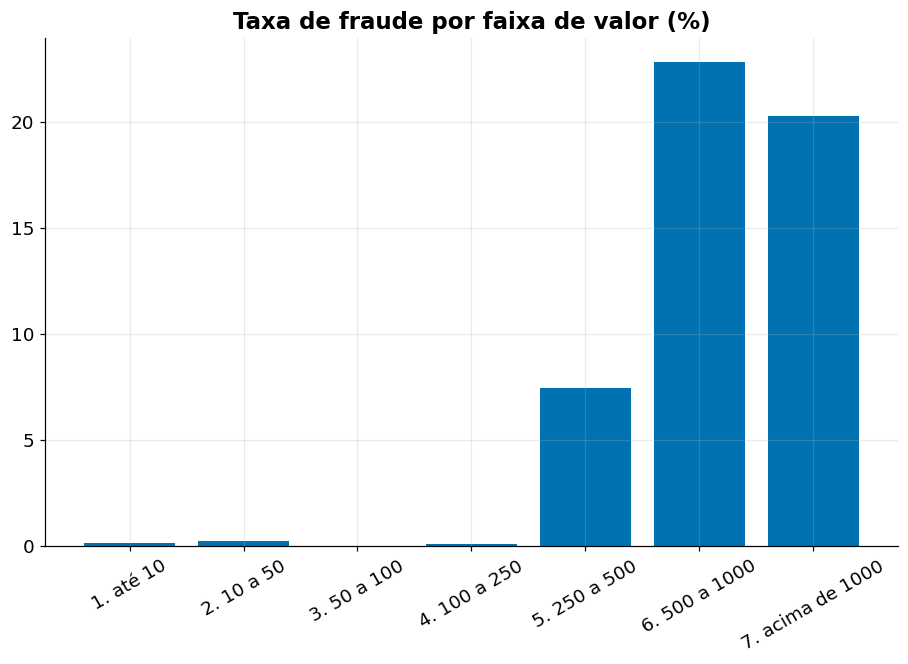

In [0]:
"""Plot fraud rate by amount band / gráfico da taxa de fraude por faixa de valor."""

plt.bar(por_faixa["faixa"], por_faixa["taxa"] * 100, color=COR_PRIMARIA)
plt.xticks(rotation=30)
plt.title("Taxa de fraude por faixa de valor (%)")
plt.show()

hour,n,taxa
0,1126105,0.015313847287775118
1,1123924,0.015063296094753738
2,1124603,0.01526316397875517
3,1123475,0.015339905204833219
4,1108712,0.00117884536290759
5,1109885,0.0011676885443086447
6,1109054,0.0011874985347873053
7,1107048,0.0012176527124388465
8,1109282,0.001149392129323292
9,1109311,0.001208858471609855


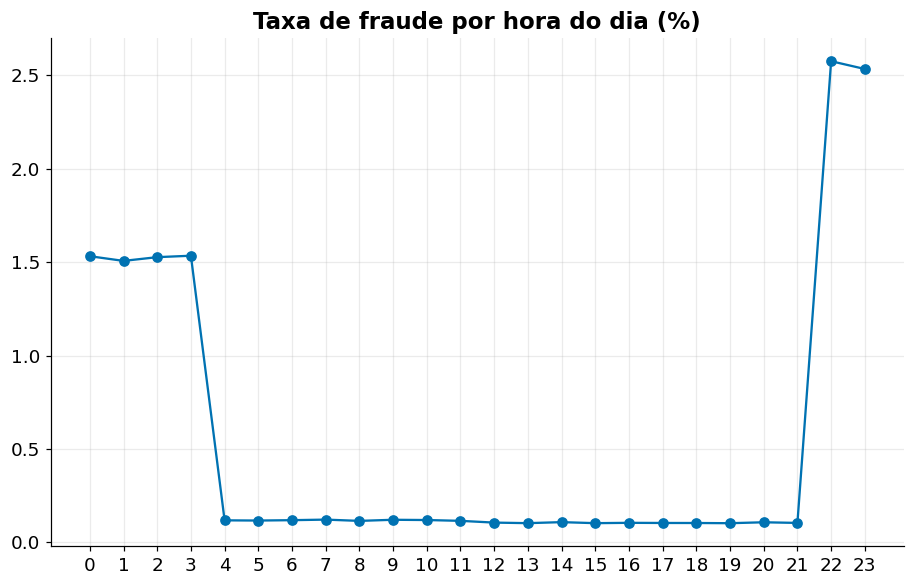

In [0]:
"""Fraud rate by hour of day / taxa de fraude por hora do dia."""

por_hora = (
    df.groupBy("hour").agg(F.count("*").alias("n"), F.avg("is_fraud").alias("taxa"))
    .toPandas().sort_values("hour")
)
display(por_hora)
plt.plot(por_hora["hour"], por_hora["taxa"] * 100, marker="o", color=COR_PRIMARIA)
plt.xticks(range(24))
plt.title("Taxa de fraude por hora do dia (%)")
plt.show()

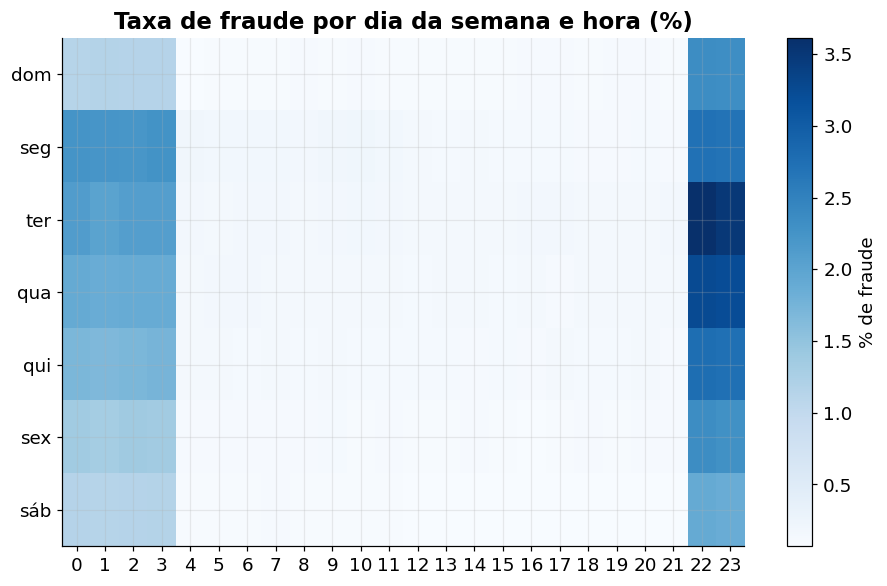

In [0]:
"""Fraud rate by weekday and hour / taxa de fraude por dia da semana e hora."""

por_dia_hora = df.groupBy("day_of_week", "hour").agg(F.avg("is_fraud").alias("taxa")).toPandas()
matriz = por_dia_hora.pivot(index="day_of_week", columns="hour", values="taxa") * 100

# spark dayofweek starts on sunday / o dayofweek do spark começa no domingo
plt.imshow(matriz, aspect="auto", cmap="Blues")
plt.colorbar(label="% de fraude")
plt.yticks(range(7), ["dom", "seg", "ter", "qua", "qui", "sex", "sáb"])
plt.xticks(range(24))
plt.title("Taxa de fraude por dia da semana e hora (%)")
plt.show()

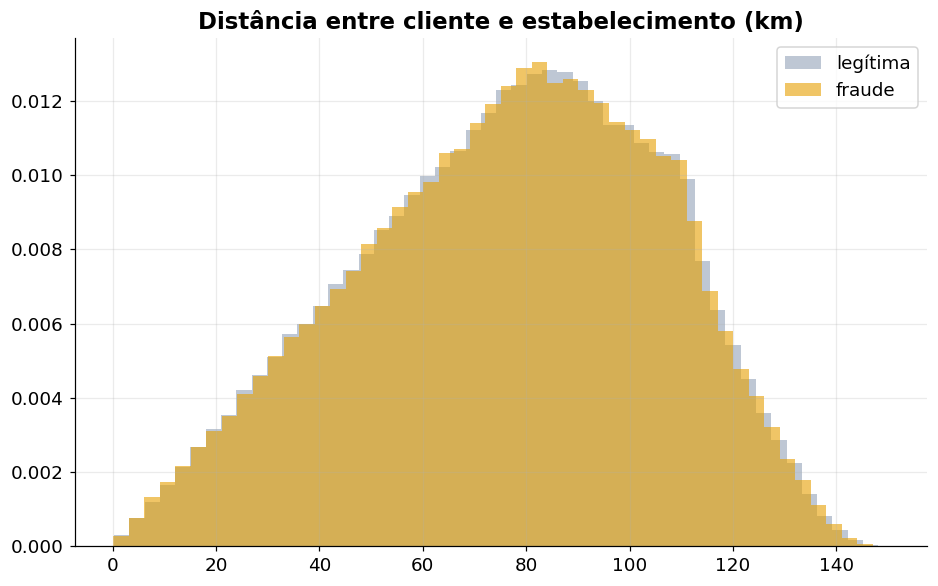

,count,mean,std,min,25%,50%,75%,max
classe,,,,,,,,
fraude,189925.0,76.512260,29.174511,0.14,55.68,78.73,98.90,150.03
legítima,207473.0,76.460885,29.205083,0.27,55.56,78.65,98.92,148.08


In [0]:
"""Distance distribution by class / distribuição da distância por classe."""

for classe, cor in [("legítima", COR_SECUNDARIA), ("fraude", COR_DESTAQUE)]:
    plt.hist(amostra.loc[amostra["classe"] == classe, "distance_km"], bins=50, density=True, alpha=0.6, color=cor, label=classe)
plt.title("Distância entre cliente e estabelecimento (km)")
plt.legend()
plt.show()
amostra.groupby("classe")["distance_km"].describe()

faixa_idade,n,taxa
10,3379646,0.005452050303493324
20,7420448,0.004057976014386193
30,7521362,0.0038882585361534254
40,6660231,0.005022048034069689
50,4094855,0.008194429350978239
60,2784178,0.008088563303064674
70,1494886,0.008306987957610146
80,1059801,0.007971307820996584
90,220971,0.007933167700739012


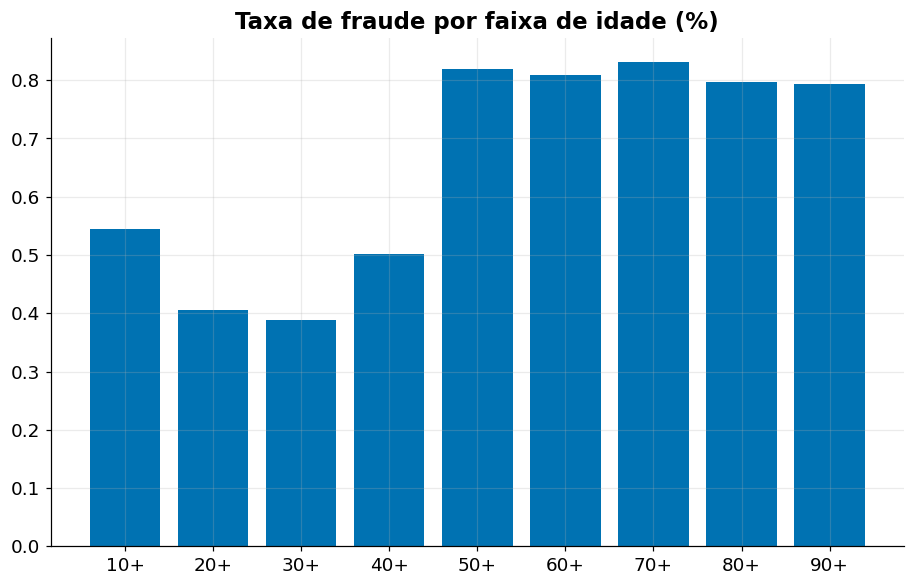

In [0]:
"""Fraud rate by age group / taxa de fraude por faixa de idade."""

# ten-year age groups / faixas de idade de dez em dez anos
por_idade = (
    df.withColumn("faixa_idade", F.floor(F.col("age") / 10) * 10).groupBy("faixa_idade")
    .agg(F.count("*").alias("n"), F.avg("is_fraud").alias("taxa"))
    .toPandas().sort_values("faixa_idade")
)
display(por_idade)
plt.bar(por_idade["faixa_idade"].astype(int).astype(str) + "+", por_idade["taxa"] * 100, color=COR_PRIMARIA)
plt.title("Taxa de fraude por faixa de idade (%)")
plt.show()

In [0]:
"""Fraud rate by month / taxa de fraude por mês."""

por_mes = (
    df.groupBy(F.date_trunc("month", "event_time").alias("mes"))
    .agg(F.count("*").alias("n"), F.sum("is_fraud").alias("fraudes"), F.avg("is_fraud").alias("taxa"))
    .toPandas().sort_values("mes")
)
display(por_mes)

mes,n,fraudes,taxa
2019-01-01T00:00:00.000Z,970166,8248,0.00850163786403564
2019-02-01T00:00:00.000Z,894861,7207,0.008053764774640978
2019-03-01T00:00:00.000Z,1361254,8086,0.005940111103438448
2019-04-01T00:00:00.000Z,1250772,7773,0.006214561886578849
2019-05-01T00:00:00.000Z,1399709,8325,0.005947664836048064
2019-06-01T00:00:00.000Z,1638624,8196,0.005001757572206925
2019-07-01T00:00:00.000Z,1601861,7852,0.004901798595508599
2019-08-01T00:00:00.000Z,1671809,8296,0.004962289352432006
2019-09-01T00:00:00.000Z,1292073,8311,0.006432299103843204
2019-10-01T00:00:00.000Z,1291812,8091,0.006263295278260304


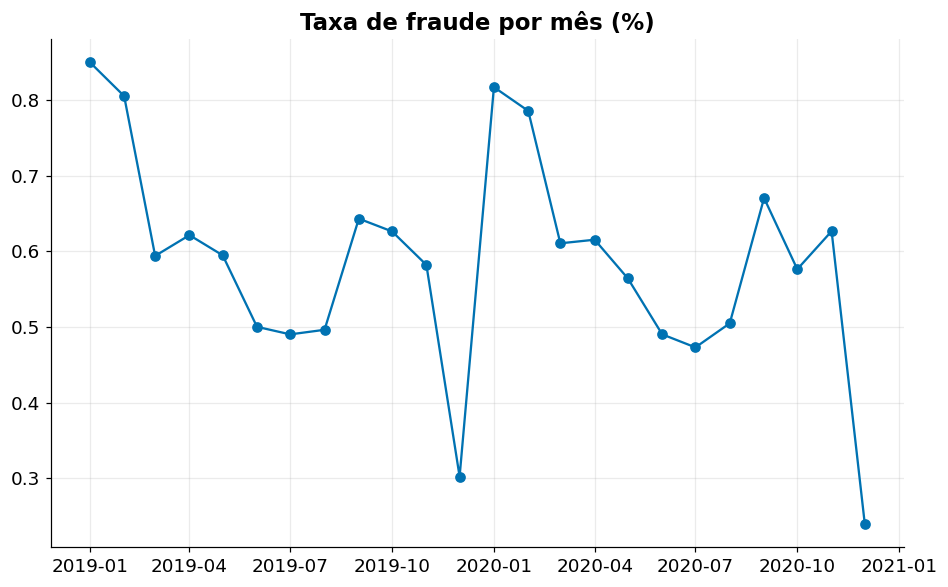

In [0]:
plt.plot(por_mes["mes"], por_mes["taxa"] * 100, marker="o", color=COR_PRIMARIA)
plt.title("Taxa de fraude por mês (%)")
plt.show()

In [0]:
"""Fraud rate by state / taxa de fraude por estado."""

# overall rate as reference / taxa geral como referência
taxa_geral = df.agg(F.avg("is_fraud")).first()[0] * 100

por_estado = (
    df.groupBy("state").agg(F.count("*").alias("n"), F.avg("is_fraud").alias("taxa"))
    .toPandas().sort_values("taxa", ascending=False)
)
display(por_estado.head(15))

state,n,taxa
RI,107001,0.006513957813478378
ND,78396,0.0063778764222664425
DC,58647,0.006257779596569304
WY,53493,0.006056867253659357
MS,288607,0.005966591246920553
WV,188149,0.005894264651951379
NE,205056,0.005852059925093633
OR,410854,0.005826887410126225
CT,399862,0.005751984434629947
AL,483210,0.005707663334781979


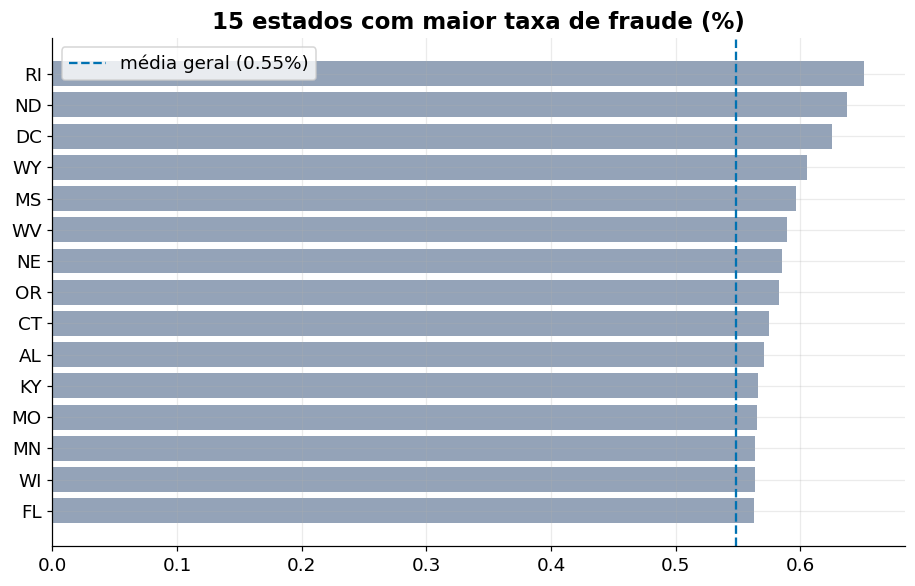

In [0]:
dados = por_estado.head(15).sort_values("taxa")
plt.barh(dados["state"], dados["taxa"] * 100, color=COR_SECUNDARIA)
plt.axvline(taxa_geral, color=COR_PRIMARIA, linestyle="--", label=f"média geral ({taxa_geral:.2f}%)")
plt.title("15 estados com maior taxa de fraude (%)")
plt.legend()
plt.show()